## Modelo 0D. 

### Ordenado y comentado por Gemini IA. [6]

In [102]:
T_end_calc = 8500

In [103]:
import numpy as np

In [104]:
# Vector de Estado Inicial y0
y0 = np.array([
    # C_V (mol/m³)
    950.0, 50.0, 0.0, 0.0,  # V2_n, V3_n, VO2_n, VO2p_n
    # C_H_total (mol/m³)
    9956.0,                 # H_total_n (3967 + 5989)
    # C_V (mol/m³)
    0.0, 0.0, 50.0, 950.0,  # V2_p, V3_p, VO2_p, VO2p_p
    # C_H_total (mol/m³)
    10950.0,                # H_total_p (4963 + 5987)
    # V (m³)
    6.0e-5, 6.0e-5          # V_n, V_p (60 mL)
])  # DATOS OBTENIDOS DE GANDOMI

# Diccionario de Parámetros Confirmados (Ajustado a Potenciostático)
params = {
    # Constantes Universales
    "F": 96485.3,       # Constante de Faraday [C/mol]
    "R": 8.314,         # Constante de Gases [J/(mol*K)]
    "T": 298.15,        # Temperatura de Operación [K] (25°C)
    "V_H2O": 18.0e-6,   # Volumen Molar del Agua [m³/mol]

    # Parámetros de Equilibrio y Concentración
    "E0": 1.26,         # Potencial Estándar de Celda (E_c - E_a) [V]
    "K2": 10.99,         # Constante de Disociación K2 [mol/m³]
    "C_S_total_neg": 6005.6, # C_S_total en Neg. [mol/m³]
    "C_S_total_pos": 6000.3, # C_S_total en Pos. [mol/m³]

    # Parámetros de Geometría
    "A_mem": 5.0e-4,    # Área de la Membrana [m²]W
    "delta": 3.56e-4,   # Espesor de la Membrana [m]

    # GANDOMI

    # --- NUEVOS PARÁMETROS: CINÉTICA Y POTENCIOSTATO ---
    "Vcell_target": 1.35, # V (Voltaje constante objetivo para DESCARGA)
    "A_cell": 1.0e-3,   # m² (Área de la celda, misma que A_mem)
    "a_c": 3.0e4,       # m²/m³ (Área específica del electrodo para el Cátodo)
    "k_c": 1.75e-7,      # m/s (Constante de velocidad estándar del Cátodo)
    "alpha_c": 0.555,     # Coeficiente de transferencia del Cátodo
    "beta": 0.5,        # Factor de sobrepotencial (50% al cátodo, 50% al ánodo)
    # ---------------------------------------------------
    # KNEHR Y GANDOMI


    # Parámetros de Crossover y Transporte
    "n_d": 1.0,         # Coeficiente de Arrastre de Agua (Electro-ósmosis)
    "Delta_phi": 0.15,  # Caída de Potencial en Membrana [V] # Aproximación
    "R_total": 4.93e-5, # Resistencia Total Específica (ASR) [Ohm*m²]
    "k_osm": 1.17e-8,   # Permeabilidad Osmótica [mol/(Pa*m²*s)] # permeabilidad osmotica/volumen molar de agua

    # ZHOU

    # Vectores de Cargas y Difusividades: [V2+, V3+, VO2+, VO2p, H+]
    "Z_K": np.array([2.0, 3.0, 2.0, 1.0, 1.0]),
    "D_K": np.array([3.125e-12, 5.93e-12, 5.0e-12, 1.17e-12, 3.35e-9])
    # KNEHR Y GANDOMI
}

In [105]:
# ==============================================================================
# DEFINICIÓN DE LA FUNCIÓN DE CORRIENTE CONSTANTE
# ==============================================================================

# Definimos el valor de corriente constante (Razonable: 50 mA/cm²)
# Para A_cell = 5 cm² -> I = -0.25 A (Negativo para descarga)
I_constant_value = -0.5

# Creamos la función que el solver necesita: I(t, params)
def constant_current_discharge(t, params):
    """
    Retorna una corriente constante para descarga galvanostática.
    Ignora 't' porque es constante, pero debe aceptarlo como argumento.
    """
    return I_constant_value

# ACTUALIZAMOS el diccionario params para usar esta función
# Esto sobrescribe cualquier valor numérico (como -0.3) que tuvieras antes
params["I_t"] = constant_current_discharge

print(f"Función de corriente actualizada. Descarga a: {I_constant_value} A")

Función de corriente actualizada. Descarga a: -0.5 A


In [106]:
import numpy as np

def calculate_transport_dynamics(y, params, I_cell):
    """
    Calcula dV/dt (cambio de volumen) y n_dot_mem (crossover) para las 10 especies
    (5 por estanque) basándose en el modelo de Wang (Electro-osmosis, Osmosis, Nernst-Planck).
    
    Entradas:
    - y: Vector de estado de 12 elementos (concentraciones y volúmenes)
    - params: Diccionario de parámetros físicos (D_k, z_k, k_osm, n_d, delta, A_mem, T, R, F, Delta_phi)
    - I_cell: Corriente de la celda [A] (variable con el tiempo)
    """
    
    # === 1. DEFINICIÓN DE CONSTANTES UNIVERSALES ===
    # Utilizamos .get para asegurar que estas constantes existen, con valores estándar si no están en params
    F = params.get("F", 96485.0)  # Constante de Faraday [C/mol]
    R = params.get("R", 8.314)    # Constante de Gases [J/(mol*K)]
    V_H2O = params.get("V_H2O", 18e-6) # Volumen Molar del Agua [m³/mol]
    T = params["T"] # Temperatura [K] (DEBE estar en params)

    # === 2. DESEMPAQUETAR CONCENTRACIONES Y VOLÚMENES ===
    # Orden de las 12 variables en el vector 'y' (CRUCIAL):
    # [0:C_V2_n, 1:C_V3_n, 2:C_VO2_n, 3:C_VO2p_n, 4:C_H_n, 
    #  5:C_V2_p, 6:C_V3_p, 7:C_VO2_p, 8:C_VO2p_p, 9:C_H_p, 
    # 10:V_n, 11:V_p]

    C_neg = y[0:5] # [C_V2_n, C_V3_n, C_VO2_n, C_VO2p_n, C_H_n]
    C_pos = y[5:10] # [C_V2_p, C_V3_p, C_VO2_p, C_VO2p_p, C_H_p]
    # V_n = y[10]
    # V_p = y[11]

    # === 3. CÁLCULO DE J_TOTAL_VOL (m/s) ===

    # C_total para Osmosis (simplificación 0D: suma de las 5 especies integradas)
    C_total_neg = np.sum(C_neg)
    C_total_pos = np.sum(C_pos)
    Delta_C_total = C_total_pos - C_total_neg

    # Electro-ósmosis (J_eo)
    J_eo = (params["n_d"] * I_cell) / (F * params["A_mem"]) * V_H2O
    
    # Ósmosis (J_osm)
    J_osm = params["k_osm"] * R * T * V_H2O * Delta_C_total
    
    # Flujo total de volumen
    J_total_vol = J_eo + J_osm

    # === 4. CÁLCULO DE dV/dt (m³/s) ===
    
    dV_neg_dt = -params["A_mem"] * J_total_vol # El volumen negativo se REDUCE si J_total_vol > 0
    dV_pos_dt = +params["A_mem"] * J_total_vol # El volumen positivo AUMENTA si J_total_vol > 0

    # === 5. CÁLCULO n_dot_mem (Crossover) para las 5 especies ===

    # Parámetros necesarios para Nernst-Planck (DEBEN ser arrays de 5 elementos en params):
    D_K = params["D_K"]    # Coeficientes de Difusión [m²/s]
    Z_K = params["Z_K"]    # Cargas iónicas (ej. [2, 3, 2, 1, 1])
    delta = params["delta"]  # Espesor de la membrana [m]
    Delta_phi = params["Delta_phi"] # Caída de potencial en la membrana [V]
    A_mem = params["A_mem"] # Área de la membrana [m²]
    
    # Diferencia y Promedio de Concentraciones
    Delta_C = C_pos - C_neg
    C_avg = 0.5 * (C_pos + C_neg)
    
    # 5.1. J_k,diff: Difusión
    J_diff = -D_K / delta * Delta_C
    
    # 5.2. J_k,mig: Migración Eléctrica
    J_mig = -Z_K * D_K * F / (R * T * delta) * C_avg * Delta_phi
    
    # 5.3. J_k,conv: Convección (Arrastre)
    J_conv = C_avg * J_total_vol
    
    # 5.4. J_k Total (Vector de 5 flujos molares)
    J_k_total = J_diff + J_mig + J_conv
    
    # 5.5. n_dot_mem (mol/s)
    # n_dot_mem_neg: Es la pérdida de moles del Negativo. -A_mem * J_k
    n_dot_mem_neg = -A_mem * J_k_total
    # n_dot_mem_pos: Es la ganancia de moles del Positivo. +A_mem * J_k
    n_dot_mem_pos = +A_mem * J_k_total

    # === 6. RETORNO DE LAS TASAS DE CAMBIO ===
    # Retornamos los 5 n_dot_mem para el negativo, los 5 para el positivo, y los 2 dV/dt
    return dV_neg_dt, dV_pos_dt, n_dot_mem_neg, n_dot_mem_pos

In [107]:
import numpy as np

# NOTA: Se asume que la función 'calculate_transport_dynamics' (Paso Anterior) 
# y la función 'I_t(t, params)' (Corriente Impuesta) están definidas y disponibles.

def rhs(t, y, params):
    """
    Calcula el vector de derivadas dy/dt para el sistema de 12 ODEs acopladas.
    
    Vector de estado y: 
    [C_V2_n, C_V3_n, C_VO2_n, C_VO2p_n, C_H_n, 
     C_V2_p, C_V3_p, C_VO2_p, C_VO2p_p, C_H_p, 
     V_n, V_p]
    """
    
    # === 1. DESEMPAQUETAR EL ESTADO Y PARÁMETROS ===
    
    # 1.1 Concentraciones y Volúmenes (CRUCIAL MANTENER ESTE ORDEN)
    C_neg = y[0:5]  # [C_V2_n, C_V3_n, C_VO2_n, C_VO2p_n, C_H_n]
    C_pos = y[5:10] # [C_V2_p, C_V3_p, C_VO2_p, C_VO2p_p, C_H_p]
    V_n, V_p = y[10], y[11]

    # 1.2 Constantes universales y Corriente
    F = params.get("F", 96485.0)
    I_cell = params["I_t"](t, params) # Corriente [A] (función definida por el usuario)
    
    # === 2. CALCULAR TÉRMINOS DE TRANSPORTE Y VOLUMEN ===
    
    dV_neg_dt, dV_pos_dt, n_dot_mem_neg, n_dot_mem_pos = \
        calculate_transport_dynamics(y, params, I_cell)
        
    # n_dot_mem_neg/pos es un vector de 5 elementos para [V2, V3, VO2, VO2p, H]

    # === 3. CÁLCULO DEL TÉRMINO FARADAICO (n_dot_cell) ===
    
    r_faradaic = I_cell / F # Tasa molar de electrones [mol/s]
    
    # Coeficientes estequiométricos (nu_k) para la dirección de OXIDACIÓN (Carga: I>0)
    # [V2+, V3+, VO2+, VO2p, H_total]
    nu_neg = np.array([-1.0, +1.0, 0.0, 0.0, 0.0])
    nu_pos = np.array([0.0, 0.0, -1.0, +1.0, +2.0]) 

    # Tasa Faradaica de moles [mol/s]
    n_dot_cell_neg = nu_neg * r_faradaic
    n_dot_cell_pos = nu_pos * r_faradaic

    # === 4. ENSAMBLAJE DE LAS 12 DERIVADAS (Ecuación Maestra) ===
    
    # El vector de derivadas final: d(y)/dt
    dy_dt = np.zeros(12)
    
    # TÉRMINOS PARA CONCENTRACIONES (10 variables)
    # Ecuación: dC_k/dt = 1/V * [ n_dot_cell + n_dot_mem - C_k * dV/dt ]
    
    # LADO NEGATIVO (Indices 0 a 4)
    # Efecto de Volumen/Dilución: C_k * dV_n/dt
    n_dot_vol_neg = C_neg * dV_neg_dt 
    
    # Suma de flujos y conversión a dC/dt (dC_k/dt = (1/V) * (n_dot_total))
    n_dot_total_neg = n_dot_cell_neg + n_dot_mem_neg - n_dot_vol_neg
    dy_dt[0:5] = n_dot_total_neg / V_n 
    
    # LADO POSITIVO (Indices 5 a 9)
    # Efecto de Volumen/Dilución: C_k * dV_p/dt
    n_dot_vol_pos = C_pos * dV_pos_dt 
    
    # Suma de flujos y conversión a dC/dt
    n_dot_total_pos = n_dot_cell_pos + n_dot_mem_pos - n_dot_vol_pos
    dy_dt[5:10] = n_dot_total_pos / V_p 
    
    # TÉRMINOS PARA VOLÚMENES (2 variables)
    dy_dt[10] = dV_neg_dt
    dy_dt[11] = dV_pos_dt
    
    return dy_dt

In [108]:
import numpy as np

def calculate_h_free(C_H_total, C_S_total, params):
    """
    Calcula la concentración de protón libre ([H+]_libre) resolviendo la ecuación 
    cuadrática derivada del equilibrio de disociación K2 del bisulfato.

    Argumentos:
    - C_H_total: Concentración total de átomos de Hidrógeno (protón libre + bisulfato) [mol/m³].
    - C_S_total: Concentración total de Azufre (sulfato + bisulfato) [mol/m³].
    - params: Diccionario de parámetros (debe contener "K2" y "unit_factor" para consistencia).

    Retorna:
    - H_free: Concentración de protón libre [H+]_libre [mol/m³].
    """
    
    # 1. Extraer K2 (constante de equilibrio)
    # Asumimos que K2 está en la misma unidad que las concentraciones (ej. mol/m³)
    K2 = params["K2"]
    
    # 2. Definir los coeficientes de la ecuación cuadrática: x² + Bx + C = 0
    # Donde x = [H+]_libre
    
    # Coeficiente A = 1.0
    B = C_S_total - C_H_total + K2
    C = -K2 * C_H_total
    
    # 3. Calcular el discriminante (Delta)
    Delta = B**2 - 4.0 * C # A=1
    
    # 4. Resolver la ecuación cuadrática (tomando solo la raíz positiva)
    if Delta < 0:
        # En una simulación física real, esto no debería ocurrir.
        # Si ocurre, indica un error en la entrada o en la física del modelo.
        raise ValueError(f"Discriminante negativo: {Delta}. Concentraciones no físicas.")

    H_free = (-B + np.sqrt(Delta)) / 2.0
    
    return H_free

In [109]:
import numpy as np

def calculate_OCV_and_Ecell(t, y, params):
    """
    Calcula el Voltaje de Circuito Abierto (E_OCV) y el Voltaje de Celda (E_cell)
    durante la operación (descarga).

    Argumentos:
    - t: Tiempo [s]
    - y: Vector de estado de 12 elementos (concentraciones y volúmenes)
    - params: Diccionario de parámetros

    Retorna:
    - E_cell: Voltaje de celda [V]
    """
    
    # Constante de protección para evitar log(0)
    epsilon = 1e-12 
    
    # === 1. DESEMPAQUETAR ESTADO Y CONSTANTES ===
    
    # Concentraciones de Vanadio (protegidas con epsilon)
    # CRUCIAL: Aplicar np.maximum(C, epsilon) a las 4 especies del Nernst.
    C_V2_n = np.maximum(y[0], epsilon)   # [V2+]_neg (Numerador)
    C_V3_n = np.maximum(y[1], epsilon)   # [V3+]_neg (Denominador)
    C_VO2_p = np.maximum(y[7], epsilon)  # [VO2+]_pos (Denominador)
    C_VO2p_p = np.maximum(y[8], epsilon) # [VO2+p]_pos (Numerador)
    
    # Concentración de Hidrógeno Total para el lado Positivo
    C_H_total_pos = y[9] 
    
    # Constantes Universales y Parámetros
    F = params.get("F", 96485.0)
    R = params.get("R", 8.314)
    T = params["T"]
    E0 = params["E0"] 
    R_total = params["R_total"]
    A_cell = params["A_cell"]       # [m^2] (NECESARIO para corregir unidades)
    
    I_cell = params["I_t"](t, params) 
    C_S_total_pos = params["C_S_total_pos"] 
    
    # === 2. CÁLCULO DE [H+] LIBRE (para el lado positivo) ===
    
    # (Asume que la función calculate_h_free está definida)
    H_free_pos = calculate_h_free(C_H_total_pos, C_S_total_pos, params)
    
    # === 3. CÁLCULO DEL VOLTAJE DE CIRCUITO ABIERTO (E_OCV) - Ecuación de Nernst ===
    
    RT_div_F = (R * T) / F
    
    # Término logarítmico (Q): Productos / Reactivos (en carga)
    # Q = (C_VO2p_p * C_V2_n * H_free_pos**2) / (C_VO2_p * C_V3_n)
    
    numerador = C_VO2p_p * C_V2_n * (H_free_pos**2)
    denominador = C_VO2_p * C_V3_n 
    
    # Nernst: Al usar np.maximum en las C_V, ya no hay riesgo de log(0)
    E_OCV = E0 + RT_div_F * np.log(numerador / denominador)
    
    # === 4. CÁLCULO DEL VOLTAJE DE CELDA (E_cell) - Ley de Ohm ===
    
    j_cell = I_cell / A_cell
    V_ohmic = j_cell * R_total

    E_cell = E_OCV + V_ohmic
    
    return E_cell

In [110]:
# Importar bibliotecas necesarias
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ==============================================================================
# --- (ASUMIMOS QUE LAS FUNCIONES Y PARÁMETROS ESTÁN DEFINIDOS AQUÍ) ---
# Se necesita: I_t, calculate_h_free, calculate_transport_dynamics, rhs, 
#              calculate_OCV_and_Ecell, y0, params
#
# Para una ejecución limpia, por favor, asegúrate de tener el código completo 
# de las funciones antes de este bloque de simulación.
# ==============================================================================

# 1. Definir el tiempo de simulación
# El tiempo de descarga total (T_end) se estima con: Q = I * T_end. 
# Capacidad Q = F * V_n * (C_V2,n_max - C_V2,n_min)
# Usaremos 2000 segundos (~33.3 minutos) como un valor inicial de prueba.
T_end = T_end_calc
t_span = (0, T_end)

print(f"Iniciando simulación galvanostática (I = {params['I_t'](0, params)} A) por {T_end} segundos...")

# 2. Ejecutar el Solucionador de ODEs (solve_ivp)
# Usamos un método robusto como RK45 o BDF (para sistemas rígidos)
solution = solve_ivp(
    # La lambda ahora acepta t, y, y el argumento extra (que sabemos que es params)
    fun=lambda t, y, params: rhs(t, y, params), 
    t_span=t_span,
    y0=y0,
    method='RK45', 
    args=(params,), # El solucionador pasa esto como el tercer argumento
    dense_output=True,
    rtol=1e-5
)

# Extraer resultados
t_sol = solution.t
y_sol = solution.y.T # Transpuesta para tener filas = tiempo, columnas = variables

print("Simulación completada con éxito.")

# 3. Post-Procesamiento: Cálculo de SOC y Voltaje a lo largo del tiempo

# Inicializar arrays de resultados
E_cell_array = np.zeros(len(t_sol))
SOC_array = np.zeros(len(t_sol))
V_n_array = y_sol[:, 10]
V_p_array = y_sol[:, 11]

# Cómputo del Voltaje y SOC en cada punto de tiempo
for i, t in enumerate(t_sol):
    # Calcular Voltaje
    E_cell_array[i] = calculate_OCV_and_Ecell(t, y_sol[i, :], params)
    
    # Calcular SOC (usando la convención del lado positivo)
    C_VO2_p = y_sol[i, 7]  # C_VO2_p (V4+)
    C_VO2p_p = y_sol[i, 8] # C_VO2p_p (V5+)
    
    # SOC = [V5+] / ([V4+] + [V5+])
    SOC_array[i] = C_VO2p_p / (C_VO2_p + C_VO2p_p)

# Convertir SOC a porcentaje
SOC_percent_array = SOC_array * 100

Iniciando simulación galvanostática (I = -0.5 A) por 8500 segundos...
Simulación completada con éxito.


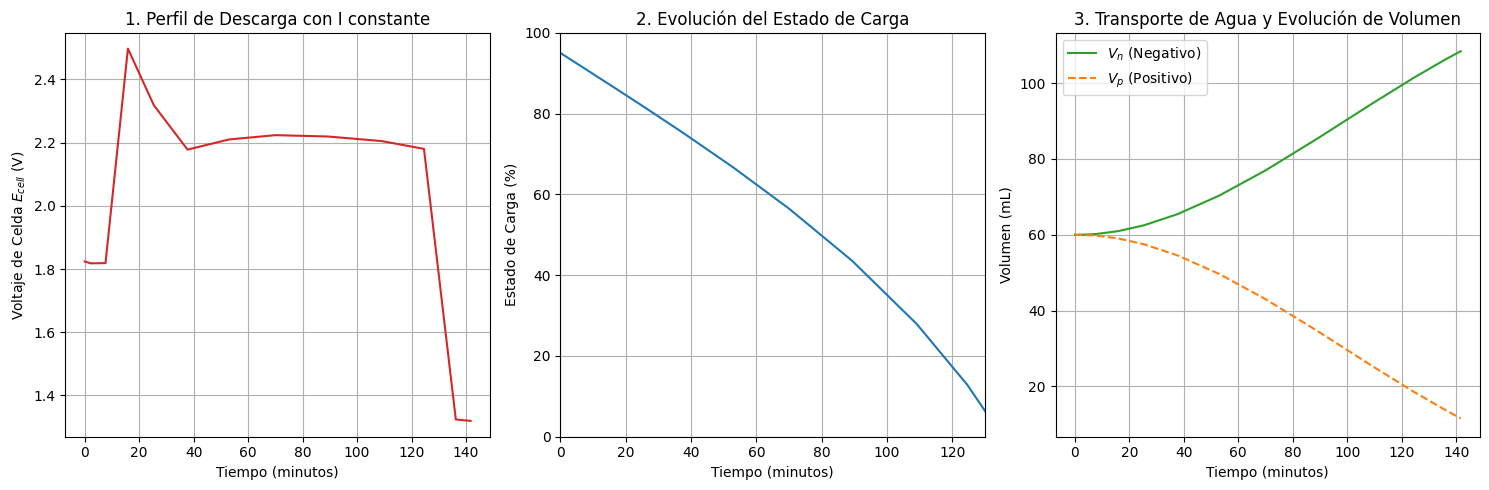

In [112]:
# ==============================================================================
# 4. Graficación de Resultados (AJUSTADA)
# ==============================================================================

# Variables (asumimos que ya fueron calculadas)
# t_sol, E_cell_array, SOC_percent_array, V_n_array, V_p_array

plt.figure(figsize=(15, 5))

# --- Factor de conversión de segundos a MINUTOS ---
tiempo_en_minutos = t_sol / 60

# --- Gráfico 1: Voltaje de Celda ---
plt.subplot(1, 3, 1)
plt.plot(tiempo_en_minutos, E_cell_array, label='Voltaje de Celda', color='tab:red')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Voltaje de Celda $E_{cell}$ (V)')
plt.title(f'1. Perfil de Descarga con I constante')
plt.grid(True)
plt.ylim(min(E_cell_array) - 0.05, max(E_cell_array) + 0.05) # Enfoca el rango relevante

# --- Gráfico 2: Estado de Carga (SOC) ---
plt.subplot(1, 3, 2)
plt.plot(tiempo_en_minutos, SOC_percent_array, label='SOC', color='tab:blue')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Estado de Carga (%)')
plt.title('2. Evolución del Estado de Carga')
# Ajuste de límites de SOC: 0 a 100%
plt.ylim(0, 100) 
plt.xlim(0,130)
plt.grid(True)

# --- Gráfico 3: Volúmenes de Tanque ---
plt.subplot(1, 3, 3)
# Convertir a mL (1e-6)
plt.plot(tiempo_en_minutos, V_n_array * 1e6, label='$V_{n}$ (Negativo)', color='tab:green')
plt.plot(tiempo_en_minutos, V_p_array * 1e6, label='$V_{p}$ (Positivo)', color='tab:orange', linestyle='--')
plt.xlabel('Tiempo (minutos)')
plt.ylabel('Volumen (mL)')
plt.title('3. Transporte de Agua y Evolución de Volumen')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()